In [ ]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 


# (Generating fresh data to ensure variables exist for the loop below)
n_items = 5000 
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(50) for _ in range(n_items)]
n_repeat_bc = 500
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
pool_bc += pool_bc[0:n_repeat_bc]
pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(3, 30) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.1), 
             "Insert": mutate_sequence(pool_ins[i], 0.1)
         })

df = pd.DataFrame(data)
if VERBOSE_LEVEL >= 1:
    print(f"Dataset: {len(df)} reads")

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

In [98]:
final_clusters

[]







Processing Top Barcode #1: CGAACCGGGA (Count: 41)
  > RapidFuzz gathered 80 reads
Analyzing cluster of 80 reads...


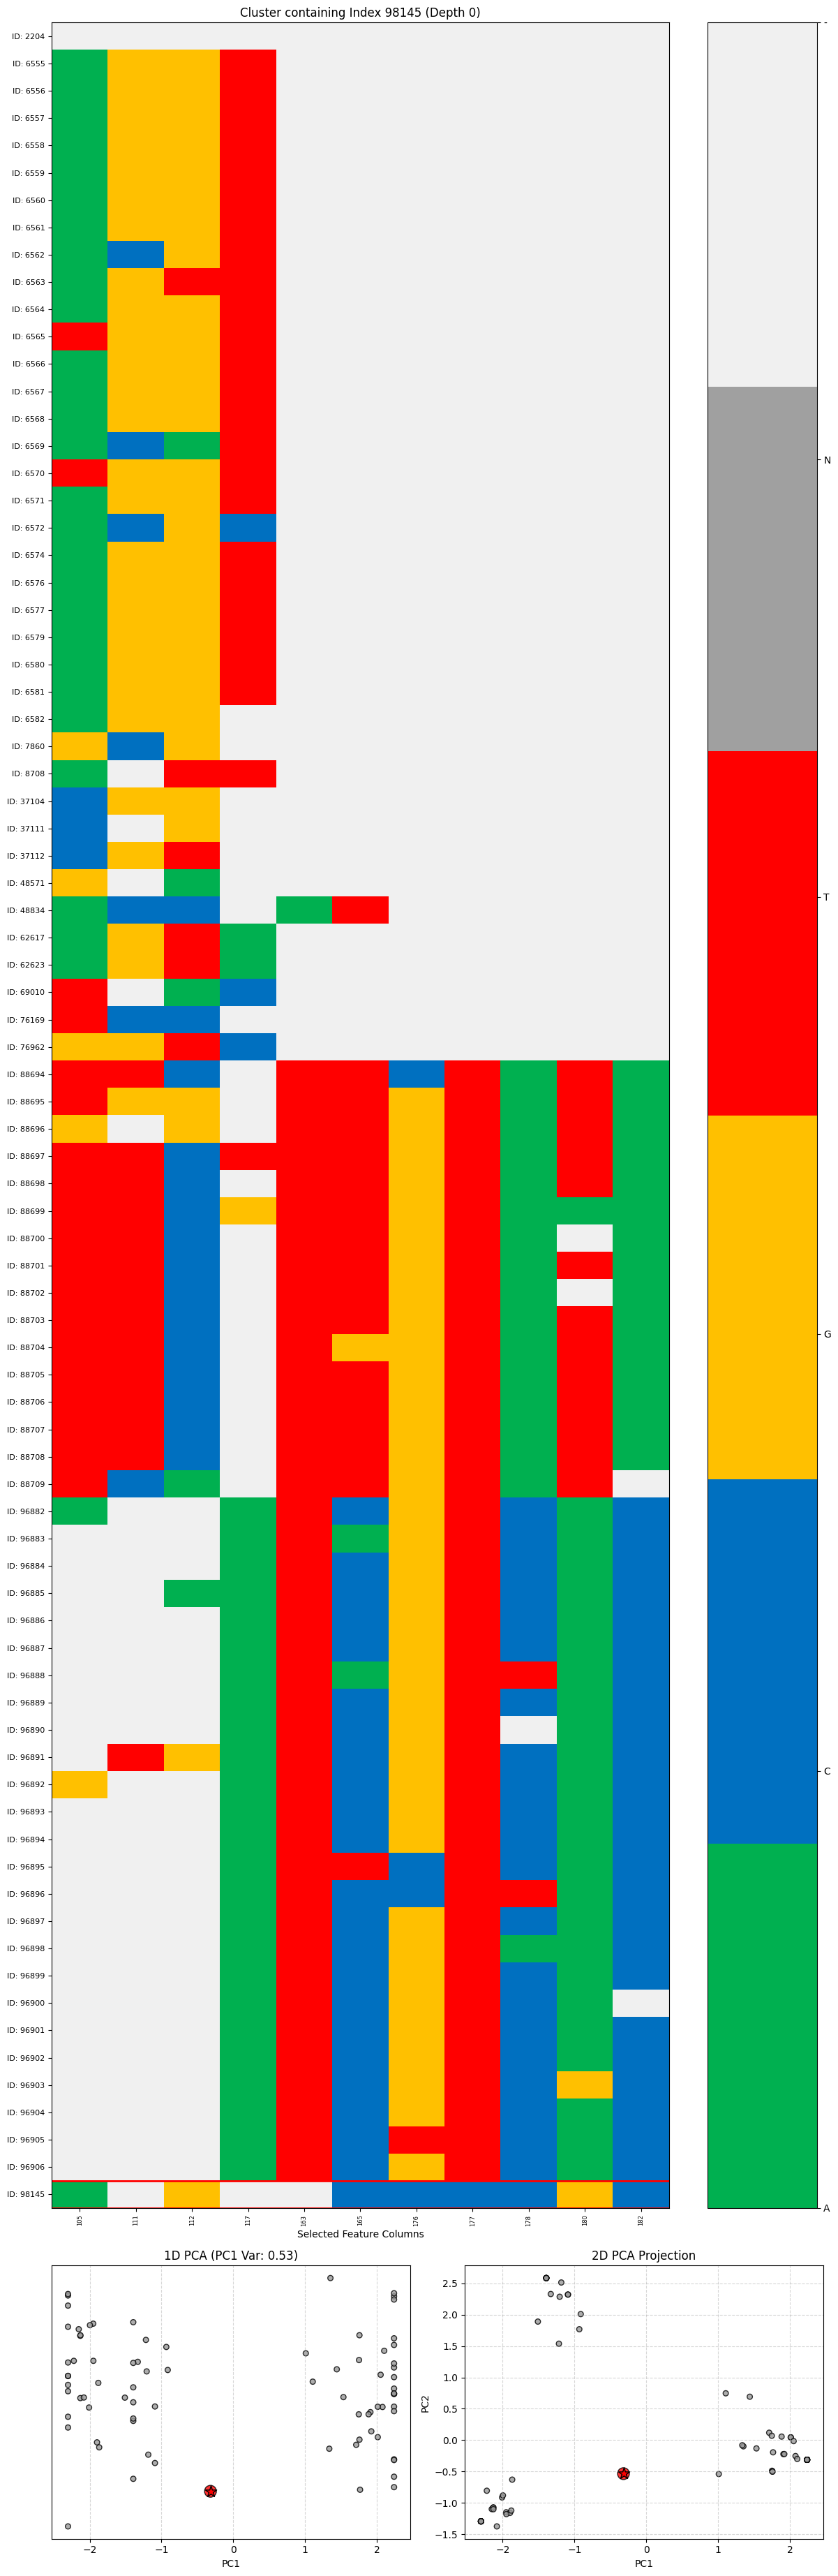

-> [CHECKING] Option 1 score weak (0.69). Running Percentile Check...
      [Opt2 Percentile] Signal Dist: 41.9 | BG 5th %ile: 33.7 | Valid: True
-> [DECISION: SPLIT] Method: Option 2 (Background Ratio Passed).
  Analyzing cluster of 38 reads...
  -> [CHECKING] Option 1 score weak (0.66). Running Percentile Check...
      [Opt2 Percentile] Signal Dist: 38.9 | BG 5th %ile: 33.7 | Valid: True
  -> [DECISION: SPLIT] Method: Option 2 (Background Ratio Passed).
    Analyzing cluster of 25 reads...
    -> [CHECKING] Option 1 score weak (0.44). Running Percentile Check...
      [Opt2 Percentile] Signal Dist: 13.5 | BG 5th %ile: 34.0 | Valid: False
    -> [DECISION: MERGE] Option 2 Failed (Indistinguishable from random noise).
    -> [SKIP] Target barcode not present in this sub-cluster.
  Analyzing cluster of 42 reads...


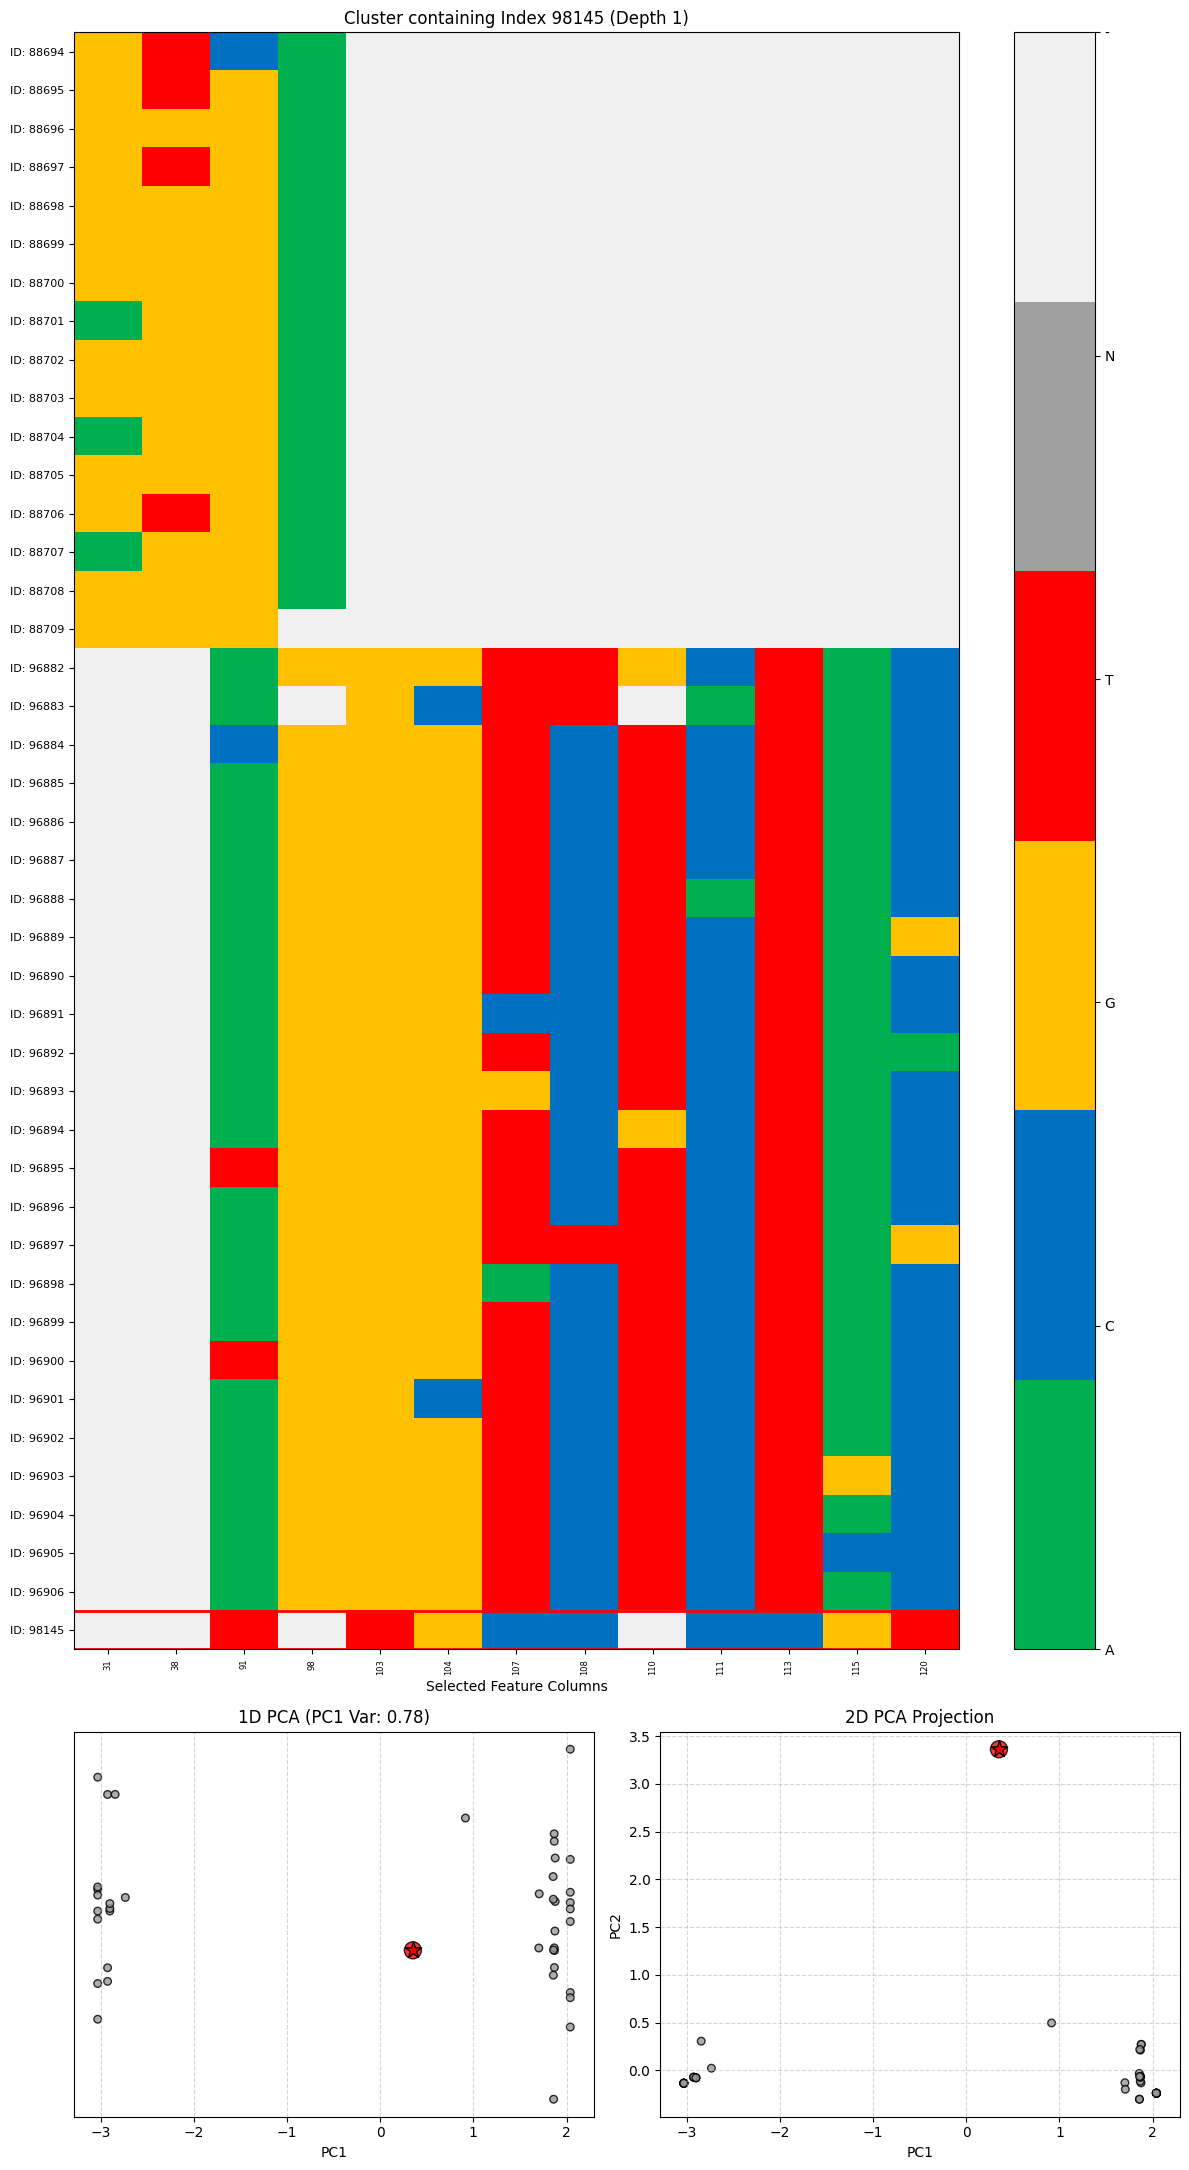

  -> [DECISION: SPLIT] Method: Option 1 (Strong Signal). Score: 0.91 > 0.8
    Analyzing cluster of 16 reads...
    -> [CHECKING] Option 1 score weak (0.57). Running Percentile Check...
      [Opt2 Percentile] Signal Dist: 12.4 | BG 5th %ile: 33.7 | Valid: False
    -> [DECISION: MERGE] Option 2 Failed (Indistinguishable from random noise).
    Analyzing cluster of 26 reads...


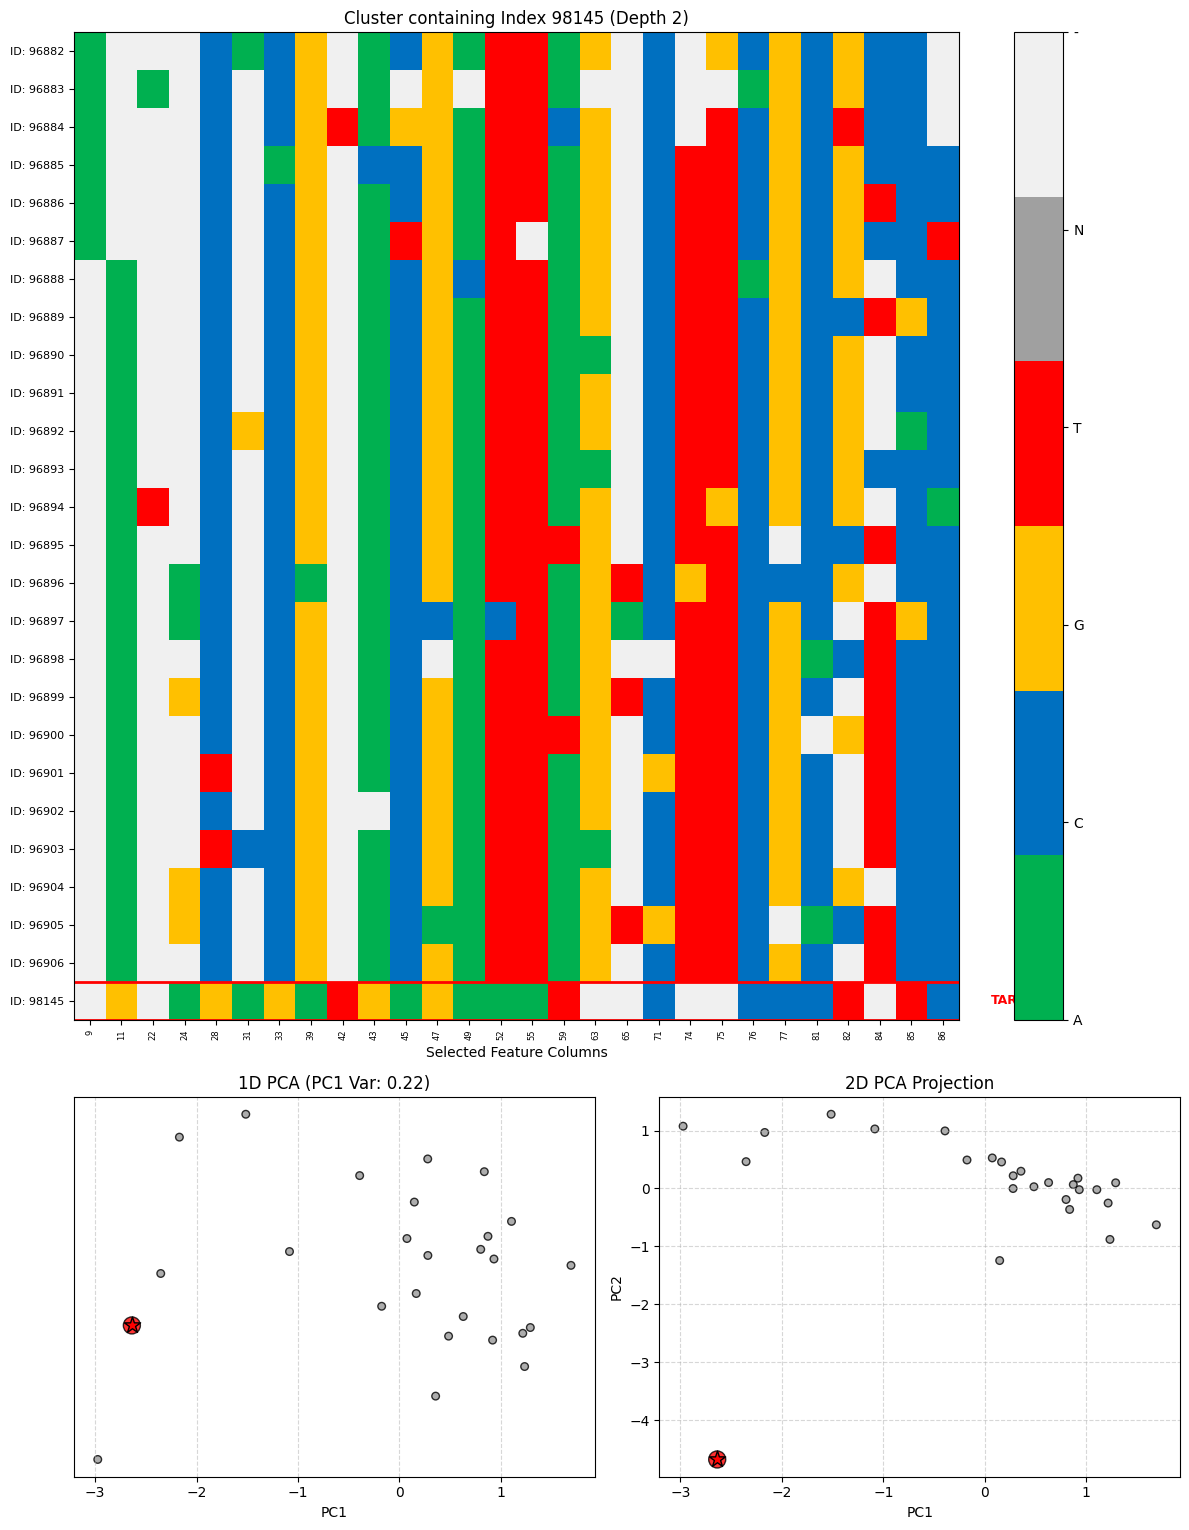

    -> [CHECKING] Option 1 score weak (0.61). Running Percentile Check...
      [Opt2 Percentile] Signal Dist: 16.4 | BG 5th %ile: 35.3 | Valid: False
    -> [DECISION: MERGE] Option 2 Failed (Indistinguishable from random noise).
    Cluster 0: 25 reads. (IDs: [406])
    Cluster 1: 16 reads. (IDs: [5406])
    Cluster 2: 26 reads. (IDs: [5906 5982])


AssertionError: 

In [160]:
# --- 1. CONFIGURATION ---
seed = 42
random.seed(seed)
np.random.seed(seed)
VERBOSE_LEVEL = 1  # Set to 1 or 2 to see output

# --- 2. DATA GENERATION ---
# (Kept identical to your script)
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# --- 3. CORE ALGORITHM FUNCTIONS ---

def encode_msa(msa_strings, alphabet="ACGTN-"):
    """Converts MSA strings to integer matrix."""
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    one_hot = np.eye(vocab_size)[msa_int]
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """Calculates Mutual Information Matrix."""
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec

def perform_pca_split_robust(msa_int, vocab_size, col_indices):
    """
    Revised: Implements Adaptive Dimensionality (1D or 2D) and Outlier Insurance.
    """
    N = msa_int.shape[0]
    msa_subset = msa_int[:, col_indices]
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(N, -1)
    
    target_n_comps = min(N, 2)
    if target_n_comps < 2: return np.zeros(N), 0.0
    
    pca = PCA(n_components=target_n_comps)
    coords = pca.fit_transform(features)
    explained_var = pca.explained_variance_ratio_[0] 
    
    if N < 5:
        if explained_var < 0.85:
            return np.zeros(N), explained_var
        labels = (coords[:, 0] > 0).astype(int)
        score = explained_var
    else:
        LINEAR_THRESHOLD_1D = 0.90
        COMPLEX_THRESHOLD_2D = 0.75

        if explained_var > LINEAR_THRESHOLD_1D:
            cluster_coords = coords[:, 0].reshape(-1, 1)
        elif explained_var < COMPLEX_THRESHOLD_2D:
            cluster_coords = coords
        else:
            cluster_coords = coords[:, 0].reshape(-1, 1)

        try:
            kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
            labels = kmeans.fit_predict(cluster_coords)
            
            count0 = np.sum(labels == 0)
            count1 = np.sum(labels == 1)
            
            is_imbalanced_split = (count0 > 0 and count0 / N < 0.10) or \
                                  (count1 > 0 and count1 / N < 0.10)
                                  
            if is_imbalanced_split:
                 score = 0.95 
            elif len(np.unique(labels)) < 2: 
                 score = 0
            else:
                 score = silhouette_score(coords, labels)
                 
        except Exception:
            labels = (coords[:, 0] > 0).astype(int)
            score = explained_var

    return labels, score


def validate_split_percentile(cluster_A_indices, cluster_B_indices, all_df, local_df,
                              percentile_th=5, n_background_target=1000, verbose=0):
    """Option 2 (Percentile Method)."""
    inserts_A = local_df.loc[cluster_A_indices, 'Insert'].tolist()
    inserts_B = local_df.loc[cluster_B_indices, 'Insert'].tolist()
    
    if not inserts_A or not inserts_B: return False

    signal_dist = 100 - process.cdist(inserts_A, inserts_B, scorer=fuzz.ratio).mean()
    
    remaining_df = all_df.drop(local_df.index, errors='ignore')
    n_background = min(n_background_target, len(remaining_df))
    
    if n_background < 10: 
        if verbose >= 2:
            print(f"      [Opt2] Warning: Low background (N={n_background}). using raw threshold.")
        return signal_dist > 15.0

    random_inserts = remaining_df.sample(n=n_background)['Insert'].tolist()
    bg_dists_A = 100 - process.cdist(inserts_A, random_inserts, scorer=fuzz.ratio)
    bg_dists_B = 100 - process.cdist(inserts_B, random_inserts, scorer=fuzz.ratio)
    
    threshold_value = (np.percentile(bg_dists_A, percentile_th) + np.percentile(bg_dists_B, percentile_th))/2
    
    is_valid = signal_dist > threshold_value 
    
    if verbose >= 2:
        print(f"      [Opt2 Percentile] Signal Dist: {signal_dist:.1f} | BG {percentile_th}th %ile: {threshold_value:.1f} | Valid: {is_valid}")
        
    return is_valid


def get_elbow_columns(mi_matrix, exclusion_distance=5):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    sorted_indices = np.argsort(scores)[::-1]
    cap = min(100, len(sorted_indices))
    sorted_indices = sorted_indices[:cap]
    sorted_scores = scores[sorted_indices]
    
    if len(sorted_scores) < 3:
        sel_rows = rows[sorted_indices]
        sel_cols = cols[sorted_indices]
        return np.unique(np.concatenate([sel_rows, sel_cols]))

    n_points = len(sorted_scores)
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (sorted_scores - sorted_scores.min()) / (sorted_scores.max() - sorted_scores.min() + 1e-9)
    
    line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line_vec = line_vec / np.linalg.norm(line_vec)
    
    vec_from_start = np.stack([x_norm - x_norm[0], y_norm - y_norm[0]], axis=1)
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    elbow_idx = np.argmax(distances)
    n_selected = max(1, elbow_idx)
    selected_indices = sorted_indices[:n_selected]
    
    sel_rows = rows[selected_indices]
    sel_cols = cols[selected_indices]
    return np.unique(np.concatenate([sel_rows, sel_cols]))


def plot_msa_and_pca(msa_int, sub_df_indices, top_cols, vocab_size, title, target_index):
    """
    Plots:
    1. Heatmap of the MSA subset.
    2. 1D PCA (PC1).
    3. 2D PCA (PC1 vs PC2).
    Highlights the target index in all plots.
    """
    
    # --- A. PREPARE DATA ---
    alphabet = "ACGTN-"
    cmap_colors = ['#00B050', '#0070C0', '#FFC000', '#FF0000', '#A0A0A0', '#F0F0F0']
    cmap = colors.ListedColormap(cmap_colors[:len(alphabet)])
    
    # Slice MSA
    msa_subset = msa_int[:, top_cols]
    read_indices = sub_df_indices.tolist()
    N = len(read_indices)

    # Calculate PCA locally for visualization
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(N, -1)
    
    pca_vis = PCA(n_components=min(N, 2))
    coords = pca_vis.fit_transform(features)
    
    # Handle Target Logic
    try:
        target_idx_loc = read_indices.index(target_index)
        is_target_present = True
    except ValueError:
        target_idx_loc = -1
        is_target_present = False

    # Colors for PCA Scatter
    # Grey for normal, Red/Gold for target
    scatter_colors = ['#999999'] * N
    sizes = [30] * N
    z_orders = [1] * N
    
    if is_target_present:
        scatter_colors[target_idx_loc] = 'red'
        sizes[target_idx_loc] = 150
        z_orders[target_idx_loc] = 10

    # --- B. PLOTTING SETUP ---
    # Create a GridSpec: Top row for Heatmap, Bottom row for PCAs
    fig = plt.figure(figsize=(12, 0.4 * N + 5)) 
    gs = gridspec.GridSpec(2, 2, height_ratios=[max(1, 0.4*N), 4])
    
    # 1. MSA HEATMAP (Spans both columns of top row)
    ax_msa = fig.add_subplot(gs[0, :])
    
    y_labels = [f"ID: {idx}" for idx in read_indices]
    im = ax_msa.imshow(msa_subset, aspect='auto', cmap=cmap, 
                       interpolation='nearest', vmin=0, vmax=len(alphabet) - 1)
    
    ax_msa.set_title(title, fontsize=12)
    ax_msa.set_yticks(np.arange(N))
    ax_msa.set_yticklabels(y_labels, fontsize=8)
    ax_msa.set_xticks(np.arange(len(top_cols)))
    ax_msa.set_xticklabels(top_cols, rotation=90, fontsize=6)
    ax_msa.set_xlabel("Selected Feature Columns")

    # Highlight target in Heatmap
    if is_target_present:
        ax_msa.axhline(y=target_idx_loc - 0.5, color='red', linewidth=2)
        ax_msa.axhline(y=target_idx_loc + 0.5, color='red', linewidth=2)
        ax_msa.text(len(top_cols) + 0.5, target_idx_loc, 'TARGET', 
                    color='red', weight='bold', fontsize=9, va='center')

    # Colorbar for Heatmap
    cbar = plt.colorbar(im, ax=ax_msa, ticks=np.arange(len(alphabet)))
    cbar.ax.set_yticklabels(list(alphabet))

    # 2. 1D PCA PLOT (Bottom Left)
    ax_pca1 = fig.add_subplot(gs[1, 0])
    
    # X = PC1, Y = Random Jitter (to see density) or 0
    jitter = np.random.normal(0, 0.05, N)
    ax_pca1.scatter(coords[:, 0], jitter, c=scatter_colors, s=sizes, 
                    alpha=0.8, edgecolors='k', zorder=1)
    
    if is_target_present:
        # Re-plot target on top to ensure visibility
        ax_pca1.scatter(coords[target_idx_loc, 0], jitter[target_idx_loc], 
                        c='red', s=150, marker='*', edgecolors='k', zorder=10)

    ax_pca1.set_title(f"1D PCA (PC1 Var: {pca_vis.explained_variance_ratio_[0]:.2f})")
    ax_pca1.set_xlabel("PC1")
    ax_pca1.set_yticks([])
    ax_pca1.grid(True, linestyle='--', alpha=0.5)

    # 3. 2D PCA PLOT (Bottom Right)
    ax_pca2 = fig.add_subplot(gs[1, 1])
    
    if coords.shape[1] >= 2:
        ax_pca2.scatter(coords[:, 0], coords[:, 1], c=scatter_colors, s=sizes, 
                        alpha=0.8, edgecolors='k', zorder=1)
        
        if is_target_present:
            ax_pca2.scatter(coords[target_idx_loc, 0], coords[target_idx_loc, 1], 
                            c='red', s=150, marker='*', edgecolors='k', zorder=10)
            
        ax_pca2.set_xlabel("PC1")
        ax_pca2.set_ylabel("PC2")
    else:
        ax_pca2.text(0.5, 0.5, "N < 2: No 2nd Component", ha='center')

    ax_pca2.set_title("2D PCA Projection")
    ax_pca2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


def recursive_analysis(sub_df, all_df, barcode_target, depth=0, OPT1_THRESHOLD=0.8, verbose=0):
    """Recursive driver for MSA -> Split -> Validate."""

    if barcode_target not in set(sub_df['Barcode']):
        if verbose >= 2:
             print(f"{'  ' * depth}-> [SKIP] Target barcode not present in this sub-cluster.")
        return []
    
    if len(sub_df) < 2: return [sub_df]
    
    prefix = "  " * depth
    if verbose >= 1:
        print(f"{prefix}Analyzing cluster of {len(sub_df)} reads...")

    # A. MSA
    barcodes = sub_df['Barcode'].tolist()
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    
    inserts = sub_df['Insert'].tolist()
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    
    spacer = "--------"
    msa_strings = [b + spacer + i for b, i in zip(msa_barcodes, msa_inserts)]
    msa_int, vocab_size = encode_msa(msa_strings)
    
    # B. Feature Selection (MI)
    _, P_i = get_marginals(msa_int, vocab_size)
    one_hot = np.eye(vocab_size)[msa_int]
    mi_matrix = compute_mi_scores(one_hot, P_i)**2
    
    top_cols = get_elbow_columns(mi_matrix, exclusion_distance=5)

    if len(top_cols) == 0:
        if verbose >= 1:
            print(f"{prefix}-> [DECISION: MERGE] Elbow found no linked features.")
        return [sub_df]

    # --- PLOTTING LOGIC MODIFIED HERE ---
    TARGET_INDEX_TO_PLOT = 98145
    
    if TARGET_INDEX_TO_PLOT in sub_df.index:
        plot_msa_and_pca(
            msa_int, 
            sub_df.index, 
            top_cols,
            vocab_size,  # Added argument
            title=f"Cluster containing Index {TARGET_INDEX_TO_PLOT} (Depth {depth})",
            target_index=TARGET_INDEX_TO_PLOT
        )
    # ------------------------------------

    # C. PCA & Split Proposal
    labels, score = perform_pca_split_robust(msa_int, vocab_size, top_cols)
    
    if len(np.unique(labels)) < 2:
        if verbose >= 1:
            print(f"{prefix}-> [DECISION: MERGE] No valid split found. (Score/Var: {score:.2f})")
        return [sub_df]
    
    # D. Validation Logic
    indices_A = sub_df.index[labels == 0]
    indices_B = sub_df.index[labels == 1]

    if score > OPT1_THRESHOLD:
        if verbose >= 1:
            print(f"{prefix}-> [DECISION: SPLIT] Method: Option 1 (Strong Signal). Score: {score:.2f} > {OPT1_THRESHOLD}")
        valid = True
    else:
        if verbose >= 1:
            print(f"{prefix}-> [CHECKING] Option 1 score weak ({score:.2f}). Running Percentile Check...")
        
        valid = validate_split_percentile(indices_A, indices_B, all_df, sub_df, 
                                          percentile_th=5, verbose=verbose)

    if valid:
        if score <= OPT1_THRESHOLD and verbose >= 1:
             print(f"{prefix}-> [DECISION: SPLIT] Method: Option 2 (Background Ratio Passed).")
            
        df_A = sub_df.loc[indices_A]
        df_B = sub_df.loc[indices_B]
        
        return (recursive_analysis(df_A, all_df, barcode_target, depth + 1, OPT1_THRESHOLD, verbose) + 
                recursive_analysis(df_B, all_df, barcode_target, depth + 1, OPT1_THRESHOLD, verbose))
    else:
        if verbose >= 1:
            print(f"{prefix}-> [DECISION: MERGE] Option 2 Failed (Indistinguishable from random noise).")
        return [sub_df]

# --- 4. MAIN EXECUTION LOOP ---
# (Main execution loop remains the same as in your snippet)


VERBOSE_LEVEL = 2

# Process loop
for i, (top_bc, count) in enumerate(barcode_counts.head(100).items()):
    print("\n\n\n\n")

    top_bc = "CGAACCGGGA"
    
    if VERBOSE_LEVEL >= 2:
        print(f"\nProcessing Top Barcode #{i+1}: {top_bc} (Count: {count})")
    
    # 1. Fast Fuzzy Filter
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    indices_in_range = np.where(scores > 85)[0] 
    
    # Use real matches
    candidate_bcs = all_barcodes[indices_in_range]
        
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()
    
    if filtered_df.empty: continue
        
    if VERBOSE_LEVEL >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")
    
    # 2. Run the Deep Analysis
    final_clusters = recursive_analysis(filtered_df, df, top_bc, verbose=VERBOSE_LEVEL)
    
    if VERBOSE_LEVEL >= 0:
        # print(f"  > Result: {len(final_clusters)} distinct clusters found.")
        for idx, c in enumerate(final_clusters):
            print(f"    Cluster {idx}: {len(c)} reads. (IDs: {c['ID'].unique()})")
            assert len(c['ID'].unique()) == 1